Exercise

Use famous iris flower dataset from sklearn.datasets to predict flower species using random forest classifier.

Measure prediction score using default n_estimators (10)
Now fine tune your model by changing number of trees in your classifer and tell me what best score you can get using how many trees

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [2]:
iris=load_iris()
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [3]:
df=pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
df['target']=iris.target
df['flower_name']=df.target.apply(lambda x:iris.target_names[x])
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [5]:
## define model
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=30)
## define train and test data
X=df.drop(['target','flower_name'],axis='columns')
Y=df.target
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2)
## fit the model
model.fit(X_train,Y_train)


,n_estimators,30
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
model_score=model.score(X_test,Y_test)

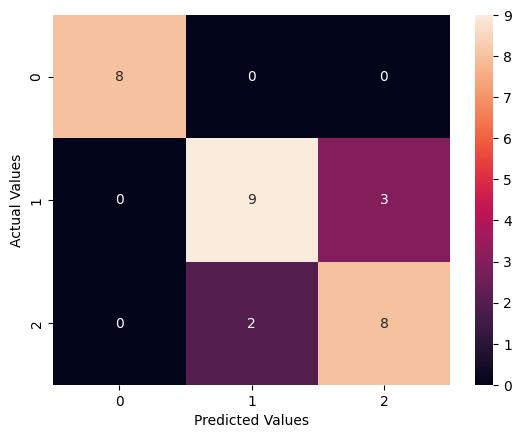

In [7]:
from sklearn.metrics import confusion_matrix
y_predicted=model.predict(X_test)
cm=confusion_matrix(Y_test,y_predicted)
sns.heatmap(cm,annot=True)
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

The confusion matrix shows that the model correctly classified all instances. Overall, the model achieved about 100% accuracy, demonstrating strong performance across all three classes when using 30 decision trees

In [8]:
print(f'Model score when n_estimators=30: {model_score* 100:.2f}%')

Model score when n_estimators=30: 83.33%


In [9]:
df.to_csv('iris_flower.csv')

Kfold cross validation

In [29]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
cross_val_score_svc=cross_val_score(SVC(),X,Y,cv=10)
cross_val_score_svc_mean=cross_val_score_svc.mean()
print(f'Cross-validation score for SVC: {cross_val_score_svc_mean* 100:.2f}%')
cross_val_score_rf_average=cross_val_score(RandomForestClassifier(),X,Y,cv=10).mean()*100
print(f'Cross-validation score for Random Forest: {cross_val_score_rf_average:.2f}%')
cross_val_score_logistic_regression=cross_val_score(LogisticRegression(max_iter=10000),X,Y)
cross_val_score_logistic_regression.mean()*100

Cross-validation score for SVC: 97.33%
Cross-validation score for Random Forest: 96.00%


np.float64(97.33333333333334)